Accepted 001/100 (global_id=1, difficulty=3.414, x_range=1.575, y_range=1.546, f1_std=0.0497, f2_std=0.1450, corr_f1_f2=-0.079)
Accepted 002/100 (global_id=2, difficulty=3.517, x_range=1.628, y_range=1.594, f1_std=0.0511, f2_std=0.1269, corr_f1_f2=-0.004)
Accepted 003/100 (global_id=3, difficulty=3.693, x_range=1.689, y_range=1.678, f1_std=0.0956, f2_std=0.1383, corr_f1_f2=-0.031)
Accepted 004/100 (global_id=4, difficulty=3.595, x_range=1.616, y_range=1.684, f1_std=0.0376, f2_std=0.1618, corr_f1_f2=0.020)
Accepted 005/100 (global_id=5, difficulty=3.290, x_range=1.532, y_range=1.500, f1_std=0.0389, f2_std=0.0964, corr_f1_f2=0.035)
Accepted 006/100 (global_id=6, difficulty=3.450, x_range=1.571, y_range=1.580, f1_std=0.0889, f2_std=0.1154, corr_f1_f2=0.008)
Accepted 007/100 (global_id=7, difficulty=3.390, x_range=1.573, y_range=1.551, f1_std=0.0404, f2_std=0.1082, corr_f1_f2=0.064)
Accepted 008/100 (global_id=8, difficulty=3.641, x_range=1.664, y_range=1.669, f1_std=0.0503, f2_std=0.1799,

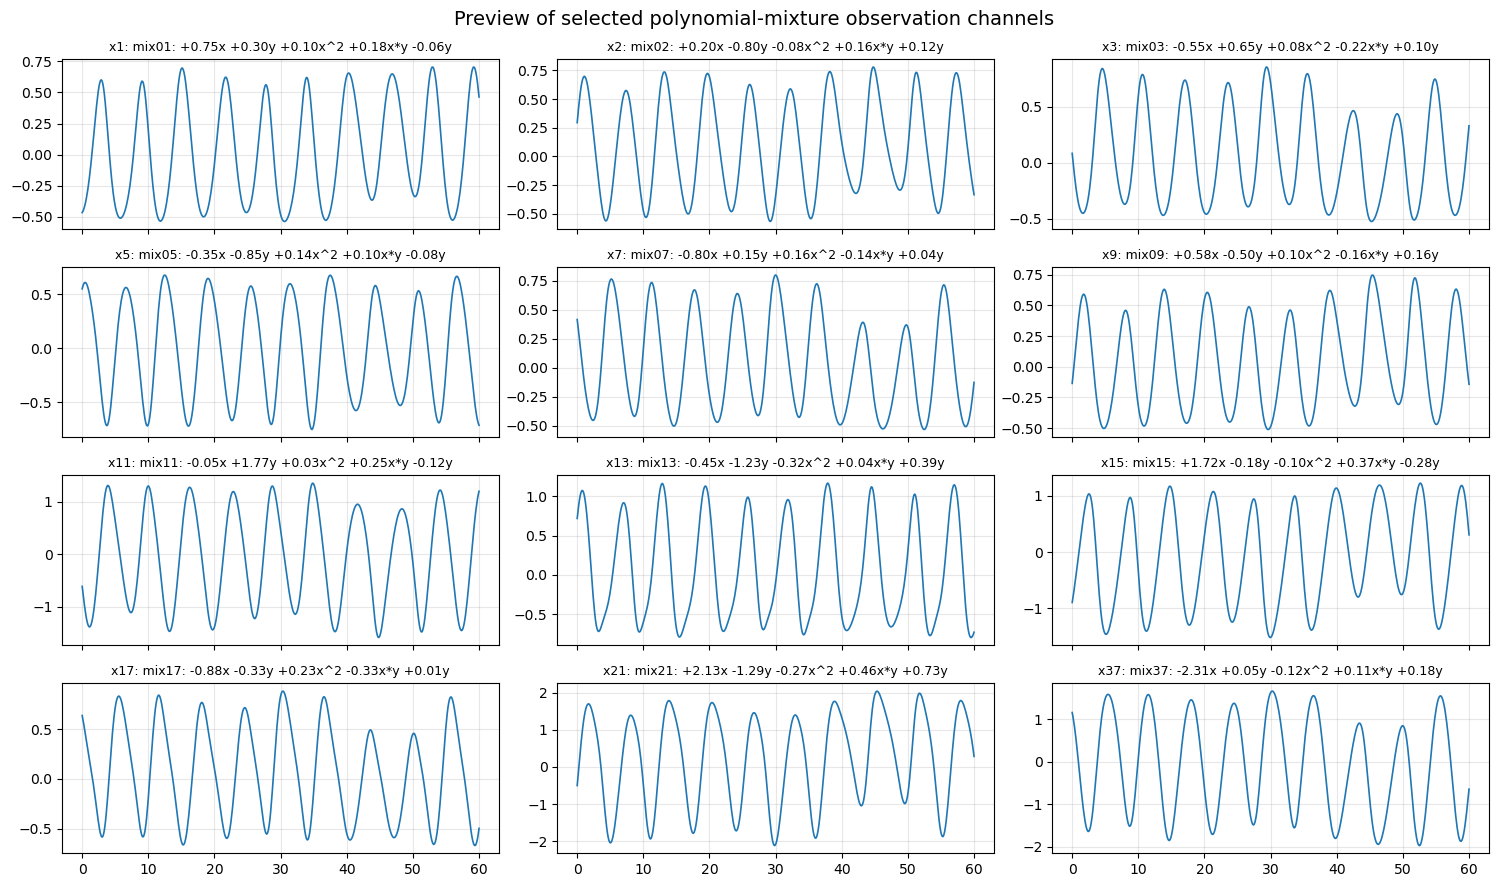

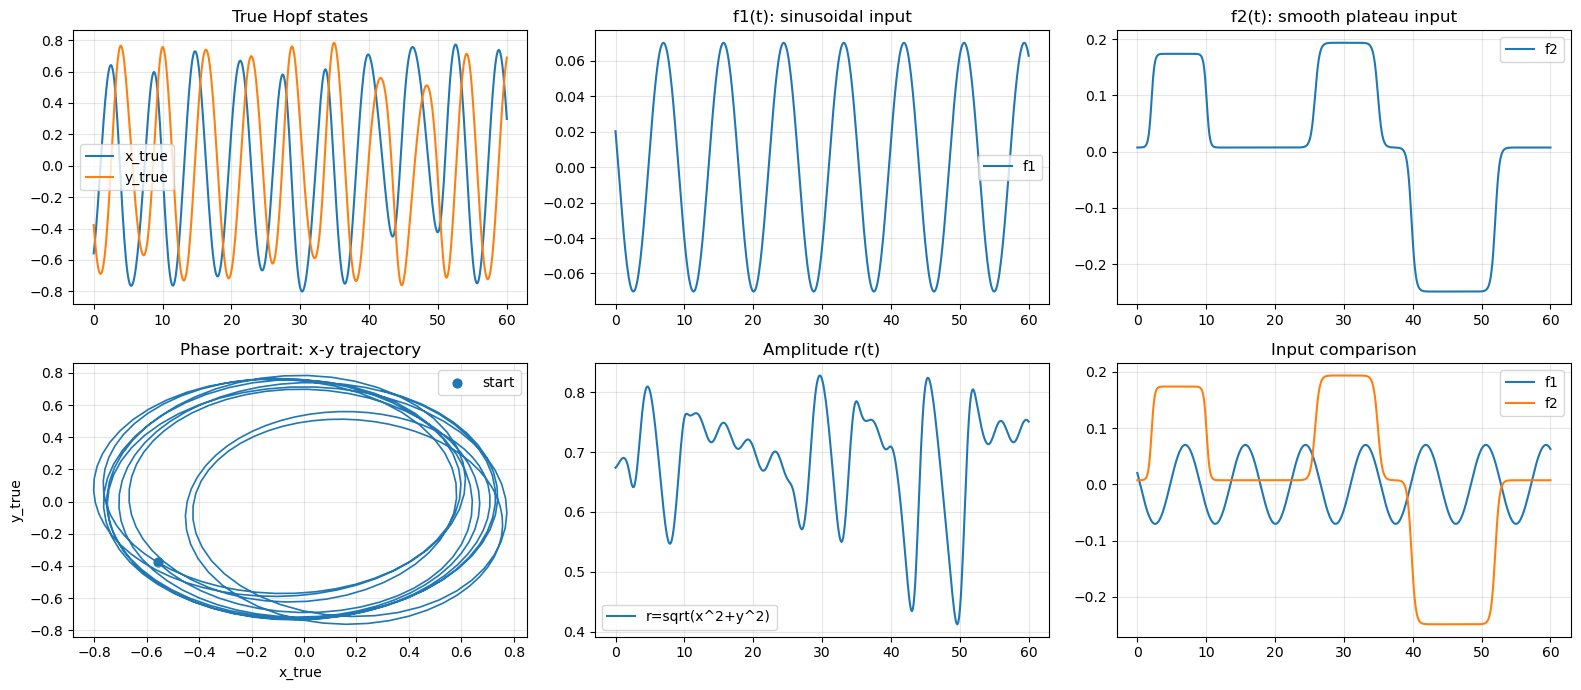

In [5]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# ============================================================
#   dx/dt = 0.5*x - 1*y - 1*(x^2+y^2)*x + f1(t)
#   dy/dt = 1*x + 0.5*y - 1*(x^2+y^2)*y + f2(t)
# ============================================================


# ======================
# Basic settings
# ======================
num_train = 80
num_var = 10
num_test = 10
num_total = num_train + num_var + num_test

seq_len = 500
high_dim = 64

root_dir = "hopf_two_input_poly_observation"
train_dir = os.path.join(root_dir, "train")
var_dir = os.path.join(root_dir, "var")
test_dir = os.path.join(root_dir, "test")

clear_existing = True
seed = 42
rng = np.random.default_rng(seed)


# ======================
# Time settings
# ======================
t_end = 60.0
T_burn = 40.0
burn_len = 800


# ======================
# Hopf system parameters
# ======================
mu = 0.5
omega = 1.0
beta = 1.0

# Unforced stable limit-cycle radius is sqrt(mu / beta) ~= 0.707.


# ======================
# f1: moderate sinusoidal forcing
# ======================
A1_range = (0.05, 0.15)
Omega1_range = (0.7, 1.8)
phi1_range = (0.0, 2.0 * np.pi)


# ======================
# f2: smooth plateau / regime-shift forcing
# ======================
A2_range = (0.1, 0.3)
num_events_range = (1, 3)
event_duration_range = (8.0, 18.0)
smoothness_kappa_range = (2.5, 5.0)

f2_baseline_range = (0.0, 0.015)

max_abs_corr_f1_f2_allowed = 0.65

min_event_gap = 3.0
max_event_attempts = 300


state_limit = 5.0

min_x_range_allowed = 0.6
min_y_range_allowed = 0.6
max_x_range_allowed = 5.5
max_y_range_allowed = 5.5

max_attempts = 50000


poly_feature_names = [
    "x",
    "y",
    "x^2",
    "x*y",
    "y^2",
    "x^3",
    "x^2*y",
    "x*y^2",
    "y^3",
]

num_poly_terms = len(poly_feature_names)

obs_coef = np.zeros((high_dim, num_poly_terms), dtype=np.float64)
obs_bias = rng.uniform(-0.15, 0.15, size=(high_dim,))

for i in range(high_dim):
    obs_coef[i, 0:2] = rng.normal(0.0, 1.0, size=2)

    obs_coef[i, 2:5] = rng.normal(0.0, 0.25, size=3)

    obs_coef[i, 5:9] = rng.normal(0.0, 0.08, size=4)

    if np.linalg.norm(obs_coef[i, 0:2]) < 0.35:
        obs_coef[i, 0:2] += rng.normal(0.0, 0.8, size=2)

# A few manually specified diverse mixtures.
# None is exactly x or y.
manual_mixtures = [
    [0.75, 0.30, 0.10, 0.18, -0.06, 0.02, 0.02, -0.01, 0.01],
    [0.20, -0.80, -0.08, 0.16, 0.12, -0.01, 0.03, 0.01, -0.02],
    [-0.55, 0.65, 0.08, -0.22, 0.10, 0.02, -0.03, 0.02, 0.01],
    [0.90, -0.35, 0.02, 0.24, 0.08, 0.00, 0.03, -0.02, 0.00],
    [-0.35, -0.85, 0.14, 0.10, -0.08, 0.01, -0.02, 0.03, -0.01],
    [0.45, 0.60, -0.10, 0.20, 0.12, 0.02, 0.01, -0.02, 0.01],
    [-0.80, 0.15, 0.16, -0.14, 0.04, -0.01, 0.02, 0.00, 0.01],
    [0.12, 0.92, 0.03, 0.22, -0.14, 0.00, 0.01, -0.03, 0.02],
    [0.58, -0.50, 0.10, -0.16, 0.16, -0.02, 0.02, 0.01, -0.01],
    [-0.28, 0.70, -0.12, 0.20, 0.10, 0.02, -0.01, 0.02, 0.00],
]

for i, coef in enumerate(manual_mixtures):
    obs_coef[i, :] = np.asarray(coef, dtype=np.float64)
    obs_bias[i] = rng.uniform(-0.08, 0.08)


def build_polynomial_basis(x, y):
    return np.stack(
        [
            x,
            y,
            x ** 2,
            x * y,
            y ** 2,
            x ** 3,
            (x ** 2) * y,
            x * (y ** 2),
            y ** 3,
        ],
        axis=0,
    )


def lift_to_high_dim(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    P = build_polynomial_basis(x, y)  # [9, T]

    X = obs_bias[:, None] + obs_coef @ P
    X = X.astype(np.float32)

    if X.shape[0] != high_dim:
        raise RuntimeError(f"Expected {high_dim} lifted channels, got {X.shape[0]}.")
    if not np.all(np.isfinite(X)):
        raise RuntimeError("Non-finite values in lifted observations.")

    feature_names = []
    for i in range(high_dim):
        pieces = []
        for c, name in zip(obs_coef[i], poly_feature_names):
            if abs(c) >= 1e-8:
                pieces.append(f"{c:+.2f}{name}")
        feature_names.append(f"mix{i + 1:02d}: " + " ".join(pieces))

    return X, feature_names


# ======================
# Forcing functions
# ======================
def eval_f1(t, A1, Omega1, phi1):
    return A1 * np.sin(Omega1 * t + phi1)


def sigmoid_stable(x):
    x = np.asarray(x, dtype=np.float64)
    return np.where(
        x >= 0.0,
        1.0 / (1.0 + np.exp(-x)),
        np.exp(x) / (1.0 + np.exp(x)),
    )


def smooth_box(t, t_on, t_off, kappa):
    # Smooth approximation of an on-off rectangular event.
    return sigmoid_stable(kappa * (t - t_on)) * sigmoid_stable(kappa * (t_off - t))


def sample_f2_events():
    num_events = int(rng.integers(num_events_range[0], num_events_range[1] + 1))

    for _ in range(max_event_attempts):
        durations = rng.uniform(event_duration_range[0], event_duration_range[1], size=num_events)
        starts = rng.uniform(2.0, t_end - durations - 2.0)
        ends = starts + durations

        order = np.argsort(starts)
        starts = starts[order]
        ends = ends[order]
        durations = durations[order]

        if num_events == 1 or np.all(starts[1:] - ends[:-1] >= min_event_gap):
            return starts, ends, durations

    # Fallback: nearly uniform positions.
    durations = rng.uniform(event_duration_range[0], event_duration_range[1], size=num_events)
    centers = np.linspace(10.0, t_end - 10.0, num_events)
    starts = centers - durations / 2.0
    ends = centers + durations / 2.0
    starts = np.clip(starts, 1.0, t_end - 2.0)
    ends = np.clip(ends, starts + 2.0, t_end - 1.0)
    return starts.astype(np.float64), ends.astype(np.float64), durations.astype(np.float64)


def sample_f2_params():
    starts, ends, durations = sample_f2_events()
    num_events = len(starts)

    baseline = rng.uniform(*f2_baseline_range)
    amps = rng.uniform(A2_range[0], A2_range[1], size=num_events)
    kappas = rng.uniform(smoothness_kappa_range[0], smoothness_kappa_range[1], size=num_events)

    # Random signs make f2 a general external input, not only positive loading.
    # If you want strictly positive mortality-like forcing, replace signs by np.ones(num_events).
    signs = rng.choice(np.array([-1.0, 1.0]), size=num_events)

    return {
        "baseline": float(baseline),
        "amps": amps.astype(np.float64),
        "signs": signs.astype(np.float64),
        "starts": starts.astype(np.float64),
        "ends": ends.astype(np.float64),
        "durations": durations.astype(np.float64),
        "kappas": kappas.astype(np.float64),
    }


def eval_f2(t, params):
    t_arr = np.asarray(t, dtype=np.float64)
    val = np.full_like(t_arr, params["baseline"], dtype=np.float64)

    for A, sgn, t_on, t_off, kappa in zip(
        params["amps"], params["signs"], params["starts"], params["ends"], params["kappas"]
    ):
        val += sgn * A * smooth_box(t_arr, t_on, t_off, kappa)

    if np.isscalar(t):
        return float(val)
    return val


# ======================
# Forced Hopf system
# ======================
def hopf_two_input(t, state, A1, Omega1, phi1, f2_params):
    x, y = state

    if not np.isfinite(x) or not np.isfinite(y):
        return [0.0, 0.0]

    f1 = eval_f1(t, A1, Omega1, phi1)
    f2 = eval_f2(t, f2_params)

    r2 = x * x + y * y

    dxdt = mu * x - omega * y - beta * r2 * x + f1
    dydt = omega * x + mu * y - beta * r2 * y + f2

    return [dxdt, dydt]


def make_stop_event():
    def stop_if_invalid(t, state):
        x, y = state
        return min(
            state_limit - abs(x),
            state_limit - abs(y),
        )

    stop_if_invalid.terminal = True
    stop_if_invalid.direction = -1
    return stop_if_invalid


def is_valid_solution(sol, expected_len):
    if not sol.success:
        return False
    if sol.y.shape[1] != expected_len:
        return False

    x = sol.y[0]
    y = sol.y[1]

    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        return False
    if np.max(np.abs(x)) > state_limit or np.max(np.abs(y)) > state_limit:
        return False

    return True


def safe_corr(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


# ======================
# One sample simulation
# ======================
def simulate_one_candidate(global_id):
    A1 = rng.uniform(*A1_range)
    Omega1 = rng.uniform(*Omega1_range)
    phi1 = rng.uniform(*phi1_range)
    f2_params = sample_f2_params()

    # Random initial state before burn-in.
    # Burn-in should remove sensitivity to this arbitrary initial condition.
    y_burn0 = rng.uniform(-2.0, 2.0, size=2)

    # ----------------------
    # Burn-in
    # ----------------------
    t_burn = np.linspace(-T_burn, 0.0, burn_len, dtype=np.float64)
    stop_event = make_stop_event()

    sol_burn = solve_ivp(
        fun=lambda tt, yy: hopf_two_input(tt, yy, A1, Omega1, phi1, f2_params),
        t_span=(t_burn[0], t_burn[-1]),
        y0=y_burn0,
        t_eval=t_burn,
        method="DOP853",
        rtol=1e-8,
        atol=1e-10,
        events=stop_event,
        max_step=0.03,
    )

    if not is_valid_solution(sol_burn, burn_len):
        raise RuntimeError(f"Invalid burn-in solution at global_id={global_id}")

    y0_formal = sol_burn.y[:, -1].copy()

    # ----------------------
    # Formal segment
    # ----------------------
    t = np.linspace(0.0, t_end, seq_len, dtype=np.float64)
    f1 = eval_f1(t, A1, Omega1, phi1)
    f2 = eval_f2(t, f2_params)

    corr_f1_f2 = safe_corr(f1, f2)
    if np.isfinite(corr_f1_f2) and abs(corr_f1_f2) > max_abs_corr_f1_f2_allowed:
        raise RuntimeError("Rejected: f1 and f2 too correlated")

    stop_event = make_stop_event()

    sol = solve_ivp(
        fun=lambda tt, yy: hopf_two_input(tt, yy, A1, Omega1, phi1, f2_params),
        t_span=(t[0], t[-1]),
        y0=y0_formal,
        t_eval=t,
        method="DOP853",
        rtol=1e-8,
        atol=1e-10,
        events=stop_event,
        max_step=0.03,
    )

    if not is_valid_solution(sol, seq_len):
        raise RuntimeError(f"Invalid formal solution at global_id={global_id}")

    x = sol.y[0].astype(np.float64)
    y = sol.y[1].astype(np.float64)

    x_min = float(np.min(x))
    x_max = float(np.max(x))
    y_min = float(np.min(y))
    y_max = float(np.max(y))
    x_range = x_max - x_min
    y_range = y_max - y_min

    if x_range < min_x_range_allowed:
        raise RuntimeError("Rejected: x_range too small")
    if y_range < min_y_range_allowed:
        raise RuntimeError("Rejected: y_range too small")
    if x_range > max_x_range_allowed:
        raise RuntimeError("Rejected: x_range too large")
    if y_range > max_y_range_allowed:
        raise RuntimeError("Rejected: y_range too large")

    X_high, feature_names = lift_to_high_dim(x, y)

    f = np.stack([f1, f2], axis=1).astype(np.float32)

    sample = {
        "t": t.astype(np.float32),
        "f": f,
        "f1": f1.astype(np.float32),
        "f2": f2.astype(np.float32),
        "x_true": x.astype(np.float32),
        "y_true": y.astype(np.float32),
    }

    for i in range(high_dim):
        sample[f"x{i + 1}"] = X_high[i].astype(np.float32)

    dx = np.gradient(x, t)
    dy = np.gradient(y, t)

    difficulty = (
        x_range
        + y_range
        + 0.2 * float(np.std(dx))
        + 0.2 * float(np.std(dy))
        + 0.5 * float(np.std(f1))
        + 0.5 * float(np.std(f2))
    )

    metadata = {
        "global_id": global_id,
        "A1": float(A1),
        "Omega1": float(Omega1),
        "phi1": float(phi1),
        "x0_burn": float(y_burn0[0]),
        "y0_burn": float(y_burn0[1]),
        "x0_formal": float(y0_formal[0]),
        "y0_formal": float(y0_formal[1]),
        "x_min": x_min,
        "x_max": x_max,
        "y_min": y_min,
        "y_max": y_max,
        "x_range": float(x_range),
        "y_range": float(y_range),
        "dx_std": float(np.std(dx)),
        "dy_std": float(np.std(dy)),
        "f1_std": float(np.std(f1)),
        "f1_min": float(np.min(f1)),
        "f1_max": float(np.max(f1)),
        "f2_baseline": float(f2_params["baseline"]),
        "f2_num_events": int(len(f2_params["amps"])),
        "f2_mean": float(np.mean(f2)),
        "f2_std": float(np.std(f2)),
        "f2_min": float(np.min(f2)),
        "f2_max": float(np.max(f2)),
        "f2_range": float(np.max(f2) - np.min(f2)),
        "corr_f1_f2": float(corr_f1_f2),
        "difficulty": float(difficulty),
    }

    return sample, metadata, feature_names


# ======================
# Prepare folders
# ======================
if clear_existing and os.path.exists(root_dir):
    shutil.rmtree(root_dir)

os.makedirs(train_dir, exist_ok=True)
os.makedirs(var_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)


# ======================
# Generate samples
# ======================
samples = []
metadata_list = []
feature_names_global = None

attempt = 0
global_id = 1

while len(samples) < num_total and attempt < max_attempts:
    attempt += 1

    try:
        sample, metadata, feature_names = simulate_one_candidate(global_id)
    except RuntimeError:
        global_id += 1
        continue

    samples.append(sample)
    metadata_list.append(metadata)
    if feature_names_global is None:
        feature_names_global = list(feature_names)

    print(
        f"Accepted {len(samples):03d}/{num_total} "
        f"(global_id={global_id}, "
        f"difficulty={metadata['difficulty']:.3f}, "
        f"x_range={metadata['x_range']:.3f}, "
        f"y_range={metadata['y_range']:.3f}, "
        f"f1_std={metadata['f1_std']:.4f}, "
        f"f2_std={metadata['f2_std']:.4f}, "
        f"corr_f1_f2={metadata['corr_f1_f2']:.3f})"
    )

    global_id += 1

if len(samples) < num_total:
    raise RuntimeError(
        f"Only generated {len(samples)}/{num_total} samples after {attempt} attempts."
    )

print(f"\nAccepted {len(samples)} samples after {attempt} attempts.")


# ======================
# Stratified split by difficulty
# ======================
order = np.argsort([m["difficulty"] for m in metadata_list])
blocks = [order[i:i + 10] for i in range(0, len(order), 10)]

split_assignments = {}

for block in blocks:
    block = np.asarray(block, dtype=int)
    rng.shuffle(block)

    test_idx = block[0:1]
    var_idx = block[1:2]
    train_idx = block[2:]

    for idx in train_idx:
        split_assignments[int(idx)] = "train"
    for idx in var_idx:
        split_assignments[int(idx)] = "var"
    for idx in test_idx:
        split_assignments[int(idx)] = "test"

split_counts = {
    "train": sum(1 for v in split_assignments.values() if v == "train"),
    "var": sum(1 for v in split_assignments.values() if v == "var"),
    "test": sum(1 for v in split_assignments.values() if v == "test"),
}

expected_counts = {
    "train": num_train,
    "var": num_var,
    "test": num_test,
}

if split_counts != expected_counts:
    raise RuntimeError(f"Unexpected split counts: {split_counts}, expected {expected_counts}")


# ======================
# Save .npy files and metadata
# ======================
local_counter = {"train": 1, "var": 1, "test": 1}
metadata_rows = []

for idx, sample in enumerate(samples):
    split = split_assignments[idx]
    local_id = local_counter[split]
    local_counter[split] += 1

    if split == "train":
        save_folder = train_dir
    elif split == "var":
        save_folder = var_dir
    elif split == "test":
        save_folder = test_dir
    else:
        raise ValueError(split)

    filename = f"hopf_{local_id:03d}.npy"
    save_path = os.path.join(save_folder, filename)
    np.save(save_path, sample)

    row = dict(metadata_list[idx])
    row["split"] = split
    row["local_id"] = local_id
    row["filename"] = filename
    metadata_rows.append(row)

metadata_df = pd.DataFrame(metadata_rows)
metadata_csv = os.path.join(root_dir, "metadata.csv")
metadata_df.to_csv(metadata_csv, index=False)


# ======================
# Save lift and system parameters
# ======================
np.savez(
    os.path.join(root_dir, "generation_params.npz"),
    high_dim=np.asarray([high_dim], dtype=np.int64),
    mu=np.asarray([mu], dtype=np.float32),
    omega=np.asarray([omega], dtype=np.float32),
    beta=np.asarray([beta], dtype=np.float32),
    feature_names=np.asarray(feature_names_global, dtype=object),
    poly_feature_names=np.asarray(poly_feature_names, dtype=object),
    obs_coef=obs_coef.astype(np.float32),
    obs_bias=obs_bias.astype(np.float32),
)

print("\nDone.")
print(f"Dataset folder: {os.path.abspath(root_dir)}")
print(f"Split counts: {split_counts}")
print(f"Metadata: {metadata_csv}")


# ======================
# Diagnostics and preview plots
# ======================
def stack_observations(sample):
    return np.stack([sample[f"x{i + 1}"] for i in range(high_dim)], axis=1)  # [T,64]


def pca_diagnostics_from_samples(samples_for_diag, max_samples=None):
    X_list = []
    use_samples = samples_for_diag if max_samples is None else samples_for_diag[:max_samples]
    for s in use_samples:
        X_list.append(stack_observations(s))
    X = np.concatenate(X_list, axis=0).astype(np.float64)
    Xc = X - X.mean(axis=0, keepdims=True)
    std = Xc.std(axis=0, keepdims=True)
    std = np.where(std > 1e-12, std, 1.0)
    Xn = Xc / std
    _, sing, _ = np.linalg.svd(Xn, full_matrices=False)
    eig = sing ** 2 / max(Xn.shape[0] - 1, 1)
    ratio = eig / np.sum(eig)
    return ratio


pca_ratio = pca_diagnostics_from_samples(samples, max_samples=30)
print("\nPCA diagnostic on lifted observations:")
print(f"  PC1 ratio       = {pca_ratio[0]:.4f}")
print(f"  PC1+PC2 ratio   = {np.sum(pca_ratio[:2]):.4f}")
print(f"  PC1+...+PC5     = {np.sum(pca_ratio[:5]):.4f}")

# Show one preview sample. You can change preview_idx.
preview_idx = 0
preview = samples[preview_idx]
t = preview["t"]
X_preview = stack_observations(preview)

selected_dims = [1, 2, 3, 5, 7, 9, 11, 13, 15, 17, 21, 37]
selected_dims = [d for d in selected_dims if 1 <= d <= high_dim]

fig, axes = plt.subplots(4, 3, figsize=(15, 9), sharex=True)
axes = axes.ravel()
for ax, d in zip(axes, selected_dims):
    ax.plot(t, X_preview[:, d - 1], linewidth=1.2)
    fname = feature_names_global[d - 1] if feature_names_global is not None else f"x{d}"
    ax.set_title(f"x{d}: {fname[:45]}", fontsize=9)
    ax.grid(True, alpha=0.3)
for ax in axes[len(selected_dims):]:
    ax.axis("off")
fig.suptitle("Preview of selected polynomial-mixture observation channels", fontsize=14)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 7))

axes[0, 0].plot(t, preview["x_true"], label="x_true")
axes[0, 0].plot(t, preview["y_true"], label="y_true")
axes[0, 0].set_title("True Hopf states")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(t, preview["f1"], label="f1")
axes[0, 1].set_title("f1(t): sinusoidal input")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[0, 2].plot(t, preview["f2"], label="f2")
axes[0, 2].set_title("f2(t): smooth plateau input")
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend()

axes[1, 0].plot(preview["x_true"], preview["y_true"], linewidth=1.2)
axes[1, 0].scatter(preview["x_true"][0], preview["y_true"][0], s=40, label="start")
axes[1, 0].set_xlabel("x_true")
axes[1, 0].set_ylabel("y_true")
axes[1, 0].set_title("Phase portrait: x-y trajectory")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(t, np.sqrt(preview["x_true"] ** 2 + preview["y_true"] ** 2), label="r=sqrt(x^2+y^2)")
axes[1, 1].set_title("Amplitude r(t)")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

axes[1, 2].plot(t, preview["f1"], label="f1")
axes[1, 2].plot(t, preview["f2"], label="f2")
axes[1, 2].set_title("Input comparison")
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

fig.tight_layout()
plt.show()